<p align="center">
  <img src="./img/MSSE.png"
       width="900">
</p>

# Clay-fluid interactions

<div style="background-color:rgba(47,128,237,0.08);padding: 10px 14px;border-left: 4px solid #2F80ED;margin: 10px 0 16px 0;border-radius: 4px;"><b>🧭 How to use this notebook</b><br>
All GROMACS and Linux commands are shown separately and are intended to be copied into a <b>Linux terminal</b>. They are not Python commands and should not be executed with the standard Jupyter Python kernel. The software required to complete the tutorial is available in <code>requirements.txt</code>.</div>


## 🎯 Objective

This tutorial demonstrates how to construct, equilibrate, simulate, and analyze a **layered mineral system** using GROMACS and the **ClayFF** force field.

The software required to complete the tutorial is:
<p style="margin-top:-60px">&nbsp;</p>

| Program | Role in Tutorial | version used |
|:-------:|:----------------:|:------------:|
| GROMACS | MD simulations |    2024.4    |
| VMD | visualisation of system |    1.9.4     |
| Xmgrace | quick plotting of GROMACS outputs |    5.1.25    |
| Python |  |   3.10.19    |
| MDAnalysis | simulation analysis |    2.9.0     |
| matplotlib |  |    3.10.7    |

The figure below shows a typical protocol for the simulation of layered materials. In this tutorial, we will follow this same protocol, using a smectite clay as our layered material.

<p align="center">
  <img src="./img/gmx_workflow.svg" alt="GROMACS Simulation Workflow" width="40%">
</p>

<p align="center">
  <b>Figure 1.</b> Overview of the GROMACS simulation workflow for mineral-organic interfaces.
</p>


## 🪨 Clay Minerals

Clays are a diverse group of minerals that are found in soils and sediments throughout the world.
Their basic structural unit is a layer composed of one or two sheets of silica tetrahedra, [Si<sup>4+</sup>O<sub>5</sub>] and one sheet of divalent or trivalent metal octahedra, [M<sup>2+</sup><sub>3</sub>(OH)<sub>2</sub>O<sub>4</sub>] or [M<sup>3+</sup><sub>2</sub>(OH)<sub>2</sub>O<sub>4</sub>]. <br>
These layers are stacked on top of each other to form a 3D structure. <br>

So-called <em>isomorphous substitution</em> of tetrahedral Si<sup>4+</sup> by a M<sup>3+</sup> ion or octahedral
M<sup>3+</sup>/M<sup>2+</sup> by M<sup>2+</sup>/M<sup>1+</sup> ions result in a net negative charge on the clay mineral. This negative <em>layer charge</em> is balanced by the presence of cations (Na<sup>+</sup>, K<sup>+</sup>, Ca<sup>2+</sup>, Mg<sup>2+</sup>, ...) in the interlayer space.

<p align="center">
  <img alt="" decoding="auto" src="img/clay_sheet_structure.png" width="40%"/>
  <img alt="" decoding="auto" src="img/clay_with_IL.png" width="50%"/>
</p>

<p align="center">
  <b>Figure 2.</b> Side view illustrations of clay sheet structure and composition (left) and two stacked clay with interlayer space (right).
</p>

<br>

Today's system will be a montmorillonite in contact with water, ions and organic molecules. We will start by building the clay sheets from unit cell (<abbr>UC</abbr>) building blocks. The composition of this unit cell is the following: [Si<sup>4+</sup><sub>8</sub>O<sub>5</sub>][Al<sup>3+</sup><sub>3</sub>Mg<sup>2+</sup>(OH)<sub>2</sub>O<sub>4</sub>]<sup>-1</sup>. The -1 charge originates from one of the octahedral Al<sup>3+</sup> atoms being substituted by a Mg<sup>2+</sup> atom. <br> In the session tutorial, the atoms are colour-coded according to the following scheme:</p>

<table style="text-align: center;padding: 0;border-collapse: collapse;align-self: center;margin: 0px auto;">
    <caption>Atom type colours</caption>
    <colgroup>
        <col span="5">
    </colgroup>
    <thead>
        <tr style="border-top: 1px solid black;background-color: white;margin: 0;padding: 0;">
            <th style="font-weight: bold;border-top: 2px solid black;border-bottom: 2px solid black;background-color: lightgray;margin: 0;padding: 6px 13px;">Element</th>
            <th style="font-weight: bold;border-top: 2px solid black;border-bottom: 2px solid black;background-color: lightgray;margin: 0;padding: 6px 13px;">Colour</th>
            <th style="font-weight: bold;border-top: 2px solid black;border-bottom: 2px solid black;background-color: lightgray;margin: 0;padding: 6px 13px;color: transparent">empty</th>
            <th style="font-weight: bold;border-top: 2px solid black;border-bottom: 2px solid black;background-color: lightgray;margin: 0;padding: 6px 13px;">Element</th>
            <th style="font-weight: bold;border-top: 2px solid black;border-bottom: 2px solid black;background-color: lightgray;margin: 0;padding: 6px 13px;">Colour</th>
        </tr>
    </thead>
    <tbody>
        <tr style="border-top: 1px solid black;background-color: white;margin: 0;padding: 0;">
            <td style="margin: 0;padding: 6px 13px;">Si</td>
            <td style="margin: 0;padding: 6px 13px;background-color: yellow; font-weight: bolder">yellow</td>
            <td style="margin: 0;padding: 6px 13px;color: transparent">empty</td>
            <td style="margin: 0;padding: 6px 13px;">Al</td>
            <td style="margin: 0;padding: 6px 13px;background-color: darkcyan; color: white; font-weight: bolder">cyan</td>
        </tr>
        <tr style="border-top: 1px solid black;background-color: white;margin: 0;padding: 0;">
            <td style="margin: 0;padding: 6px 13px;">O</td>
            <td style="margin: 0;padding: 6px 13px;background-color: red; color: white; font-weight: bolder">red</td>
            <td style="margin: 0;padding: 6px 13px;color: transparent">empty</td>
            <td style="margin: 0;padding: 6px 13px;">Mg</td>
            <td style="margin: 0;padding: 6px 13px;background-color: darkviolet; color: white; font-weight: bolder">purple</tD>
        </tr>
        <tr style="border-bottom: solid 2px black;border-top: 1px solid black;background-color: white;margin: 0;padding: 0;">
            <td style="margin: 0;padding: 6px 13px;">H</td>
            <td style="margin: 0;padding: 6px 13px;background-color: white; color: black; font-weight: bolder">white</td>
            <td style="margin: 0;padding: 6px 13px;color: transparent">empty</td>
            <td style="margin: 0;padding: 6px 13px;">C</td>
            <td style="margin: 0;padding: 6px 13px;background-color: #333333; color: white; font-weight: bolder">gray</tD>
        </tr>
    </tbody>
</table>

<p align="center">
  <img alt="" decoding="auto" src="img/uc_top.png" width="35%"/>
  <img alt="" decoding="auto" src="img/uc_side.png" width="55%"/>
</p>

<p align="center">
  <b>Figure 3.</b> Montmorillonite unit cell top view (left) and side view (right).
</p>


<br>

---

## 📁 1. Project organization

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters</b><br>A structured directory hierarchy separates source coordinates, force field topologies, simulation parameter files, run trajectories, and post-processing analysis outputs.</div>

As you start to work on the tutorial, let's think about how to organise your work. Over the course of this tutorial, a lot of files will be generated. Unless you specify the names of output files, GROMACS will use default names for them. This will cause existing files to be overwritten by new ones. <br>
<i>Note:</i> GROMACS does back up old files, renaming them to <code>#&lt;filename&gt;.&lt;extension&gt;.1#</code> before overwriting.

To be able to retrieve your data later and to not get confused, make sure to keep your work organised and name files coherently. For the tutorial, each simulation step is run in a different subdirectory and the name input and output files named in a descriptive matter.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
    <h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Create the working folders </h4>
    <blockquote style="margin-top:-10px"><b>🎯 Purpose</b>: Create dedicated folders for inputs, initial structures, simulation parameter files (<code>.mdp</code>), energy minimization, equilibration, production MD, and data analysis.
    </blockquote>
    <code style="padding: 6px 10px;display:block;white-space:nowrap;margin-top:30px;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;" data-language="bash"> mkdir -p clay_interface/{system,EM,EQ,production,analysis}
    </code>

<br>

Place the provided directories (`FF/`, `MDP/` & `STRUCTURES`) into this new folder.

</div>

<br>

---

## 🧩 2. GROMACS file types

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters</b><br>GROMACS outputs many files during use, so understanding what each file contains makes later troubleshooting much easier.</div>

<br>

The important parts of the files will be discussed if and when they are needed, but a summary of the file types used is:

### 🔍 Summary of GROMACS File Types

| File Extension | File Type | Role in Workflow |
|---|---|---|
| `.gro` / `.pdb` | Coordinate file | Contains atom names, residue names, 3D Cartesian coordinates, and box dimensions. |
| `.top` | System topology | Defines included force field files, moleculetype definitions, and system molecule counts. |
| `.itp` | Included topology | Defines atom types, charges, bonds, angles, and dihedrals for individual molecule types (e.g. `MMT.itp`, `dec.itp`). |
| `.mdp` | Molecular dynamics parameters | Controls run type (EM, NVT, NPT), timestep, temperature/pressure coupling, and cutoffs. |
| `.tpr` | Compiled run input | Binary input compiled by `gmx grompp` combining structure, topology, and parameters. |
| `.xtc` | Trajectory file | Compressed trajectory storing atomic positions at specified time intervals. |
| `.edr` | Energy file | Binary file containing thermodynamic outputs (Energy, Temperature, Pressure, Density). |
| `.log` | Simulation log file | Text record of run statistics, performance metrics, and convergence details. |
| `.xvg` | Data file | Text file containing tabular data formatted for plotting (Grace / Python). |
| `.ndx` | Index file | Groups of atoms defined by serial numbers or names for selective analysis (e.g. water OW atoms). |

<br>

---

## ⚙️ 3. Force Fields
<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters</b><br>Simulating minerals requires specialized force fields like ClayFF, while organic molecules and ions have their own force fields. Understanding interaction parameters ensures correct physical behavior during simulation.</div>  
 
When using more than one force field, it is important to ensure they:
- use the same mixing rules
- parameterised for use with the same water model
- optionally, that their combination has been experimentally verified
  
<p style="margin-top:-20px">&nbsp;</p>
 
### 🔍 ClayFF Force Field

ClayFF is one of the most popular force fields used to model layered materials, the other is InterfaceFF.
ClayFF is a flexible, nonbonded force field parameterised for use with single-point charge (SPC) water (Cygan et al., *J. Phys. Chem. B* 2004).

- **Nonbonded-dominant model**: Metal-oxygen interactions (Al–O, Si–O, Mg–O) within the clay framework are treated primarily via electrostatic (Coulombic) interactions and short-range 12-6 Lennard-Jones potentials.
- **Hydroxyl bonds**: Harmonic terms uesd to desccribe bond stretch and bond angle with water molecules and hydroxyls
- **Partial Atomic Charges**: ClayFF uses partial charges derived from quantum chemical electronic structure calculations.
    <details>
    <summary>📘 Optional information: Currently supported atom types and their charges</summary>
      <ul>
          <li>Silicon (tetrahedral = <code>st</code>): $+2.1000 \, e$</li>
          <li>Aluminium (octahedral = <code>ao</code>, tetrahedral = <code>at</code>): $+1.5750 \, e$</li>
          <li>Iron III (octahedral = <code>feo</code>, tetrahedral = <code>fet</code>): $+1.5750 \, e$</li>
          <li>Iron II (octahedral = <code>fe2</code>): $+1.3600 \, e$</li>
          <li>Magnesium (octahedral = <code>mgo</code>): $+1.3600 \, e$</li>
          <li>Calcium (octahedral = <code>cao</code>): $+1.3600 \, e$</li>
          <li>Lithium (octahedral = <code>lio</code>): $+0.5250 \, e$</li>
          <li>Hydroxide Magnesium (<code>mgh</code>): $+1.0500 \, e$</li>
          <li>Hydroxide Calcium (<code>cah</code>): $+1.0500 \, e$</li>
          <li>Hydroxyl Hydrogen (<code>ho</code>): $+0.4250 \, e$</li>
          <li>Hydroxyl Oxygen (<code>oh</code>): $-0.9500 \, e$</li>
          <li>Dioctahedral Hydroxyl Oxygen with sub (<code>ohs</code>): $-1.0808 \, e$</li>
          <li>Trioctahedral Hydroxyl Oxygen with sub (<code>oxs</code>): $-0.9742 \, e$</li>
          <li>Dioctahedral Bridging Oxygen (<code>ob</code>): $-1.0500 \, e$</li>
          <li>Trioctahedral Bridging Oxygen (<code>ox</code>): $-1.2825 \, e$</li>
          <li>Dioctahedral Bridging Oxygen with octa sub (<code>obos</code>): $-1.1808 \, e$</li>
          <li>Trioctahedral Bridging Oxygen with octa sub (<code>oxos</code>): $-1.3100 \, e$</li>
          <li>Bridging Oxygen with tetra sub (<code>obts</code>): $-1.1688 \, e$</li>
          <li>Bridging Oxygen with 2x subs (<code>obss</code>): $-1.2996 \, e$</li>
      </ul>
    </details>
- **Combination Rules**: Uses **Lorentz-Berthelot** combination rules (`comb-rule = 2`):
  $$\sigma_{ij} = \frac{\sigma_i + \sigma_j}{2}, \quad \epsilon_{ij} = \sqrt{\epsilon_i \cdot \epsilon_j}$$

<div style="border-left: 4px solid #F2994A;background-color:rgba(242,153,74,0.08);padding: 10px 14px;margin: 10px 0;border-radius: 4px;"><b>⚠️ Note on GROMACS Warning</b><br>
<p style="margin-top:10px">When processing the topology of ClayFF with <code>gmx grompp</code>, GROMACS emits a warning: 
<code style="margin-top:10px;display:block;white-space:pre-wrap;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;" data-language="bash">NOTE 3 [file MMT_slab_dec_solv.top, line 40]:
In moleculetype 'MMT' 32 atoms are not bound by a potential or constraint
to any other atom in the same moleculetype. Although technically this
might not cause issues in a simulation, this often means that the user
forgot to add a bond/potential/constraint or put multiple molecules in
the same moleculetype definition by mistake. Run with <code>-v</code> to get
information for each atom.</code></p>
Because ClayFF is a nonbonded framework force field, framework atoms interact via Coulombic and LJ potentials rather than explicit harmonic bonds. <b>This is expected behavior and not an error.</b> Use <code>-maxwarn 1</code> during <code>gmx grompp</code> for initial ion generation.
</div>

<p style="margin-top:-20px">&nbsp;</p>

### 🔍 Other Force Fields Used
The Ions.ff force field contains parameters that accurately reproduce ion-oxygen distances (IOD). It uses 12-6 Lennard-Jones potentials, but a more accurate 12-6-4 model is available from the same authors if ions with d or f electrons are used. (Smith et al., *J. Chem. Theory Comput.* 2023)
<br>
This tutorial also uses the CHARMM36 force field for the organics, which has all standard bonded and non-bonded terms plus an additional Urey-Bradley bond-angle vibration term. (Best et al., *J. Chem. Theory Comput.* 2012)

<br>

---

## 🖥️ 4. Visualising Structures with VMD

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters</b><br>Visualising molecular structures at each step of the preparation workflow allows you to verify that coordinates, box dimensions, periodic boundaries, and atomic environments are correct before submitting simulations.</div>

<a href="https://www.ks.uiuc.edu/Research/vmd/" target="_blank">Visual Molecular Dynamics (VMD)</a> is a widely used molecular visualisation program for displaying, animating, and analysing large biomolecular and material systems.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Getting started with VMD </h4>

> 🎯 **Purpose:** Learn how to launch VMD, navigate 3D structures, customize representations, and inspect simulation boxes.

<br>

**1. Launching VMD:**
Open a terminal and launch VMD by typing:
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">vmd</code>

<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
    The startup of VMD opens two separate windows:
    <ul>
        <li><b>VMD Main:</b> Used to manage loaded molecules, control trajectory animation frames, and access menu options.</li>
        <li><b>OpenGL Display:</b> The 3D interactive viewport where your molecular system is rendered.</li>
    </ul>
    You can also open coordinates directly from the terminal by providing the file path:
    <code>vmd STRUCTURES/MMT.gro</code>
</blockquote>

<p align="center">
  <img src="./img/vmd.png" width="60%">
</p>
<p align="center"><b>Figure 4.</b> VMD Main window, OpenGL Display viewport, and the Molecule File Browser window.</p>

<br>

**2. Mouse navigation in the OpenGL display:**
Click and drag within the 3D display window to move the view:
- Press <code>R</code>: **Rotate mode** (default) — rotates the camera around the system.
- Press <code>T</code>: **Translate mode** — translates/pans the system across the screen.
- Press <code>S</code>: **Scale mode** — zooms in and out by dragging left/right or up/down.
- Press <code>=</code> or go to `Display` &rarr; `Reset View` to re-center and reset the camera.

<br>

**3. Changing Graphical Representations:**
Go to `Graphics` &rarr; `Representations...` in the VMD menu bar.
- **Drawing Method:** Change how atoms are drawn:
  - `Licorice` / `CPK`: Useful for mineral frameworks and organic chains (draws bonds and atoms as cylinders and spheres).
  - `VDW`: Draws full van der Waals spheres (ideal for ions like Na⁺).
  - `Lines`: Lightweight representation for large water solvent boxes.
  - `QuickSurf`: Generates a continuous molecular surface (useful for viewing solvent surfaces with transparent materials).
- **Coloring Method:** Change coloring scheme (`Element`, `Name`, `Type`, `ResName`, or `ColorID`).
- **Selected Atoms:** Control which subset of atoms is shown. Click `Create Rep` to add new layers, and type selection keywords:
  - `all`: All atoms in the molecule.
  - `resname MMT`: Clay sheet framework atoms.
  - `resname DECA`: Decanoic acid organic molecules.
  - `resname SOL`: Water solvent molecules (`name OW` selects water oxygens).
  - `resname NA` or `name NA`: Sodium counterions.
  - `within 5 of resname MMT`: Atoms within 5 Å (0.5 nm) of the clay surface.
  - `serial 1234`: Selects a specific atom by its serial number (useful when diagnosing energy minimisation issues).

<br>

**4. Visualising the Simulation Box:**
To draw the simulation box boundaries in VMD, open the Tk Console (`Extensions` &rarr; `Tk Console`) or type in the terminal console:
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">pbc box</code>

To quit VMD, type <code>exit</code> in the terminal or close the VMD Main window.

</div>

<br>

---


## 🧱 5. Building the Layered System

In this section, we assemble the complete 3D periodic system step-by-step:
1. **Expand the MMT unit cell** into a 2D periodic sheet.
2. **Extend the simulation box** along the z-axis to create space for solvent/organics.
3. **Insert decanoic acid molecules** above the clay surface.
4. **Solvate the system** with water molecules.
5. **Neutralise the net negative framework charge** by adding $\text{Na}^+$ counterions.

<p style="margin-top:-20px">&nbsp;</p>

### 5.1 Build the clay sheet

To build a realistic natural clay, it is recommended to use the package <a href="https://claycode.readthedocs.io/en/latest/" target="_blank">ClayCode</a>. This generates clay mineral structures based upon their natural partially occupied unit cell compositions and assigns ClayFF force field parameters, generating input files ready for simulation with GROMACS software. There are step-by-step tutorials available online. <br>
Alternatively, unit cells can be replicated to create clay slabs using GROMACS.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Use <a target="_blank" href="https://manual.gromacs.org/current/onlinehelp/gmx-genconf.html"><code style="color: #004f71;">genconf</code></a> to create a single clay sheet from the <abbr>MMT</abbr> <abbr>UC</abbr> </h4>

> 🎯 **Purpose:** Generate a continuous 2D clay layer.

<br>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx genconf -f STRUCTURES/MMT.gro -nbox &lt;x_ucs&gt; &lt;y_ucs&gt; &lt;z_ucs&gt; -o system/MMT_slab.gro</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
    <code>-f</code> specifies the structure file of the system to insert into <br>
    <code>-nbox</code> defines the number of unit cells to put in each of the <em>x y z</em> directions <br>
    <code>-o</code> specifies the output file name <br>
</blockquote>
<br>
How many <abbr>UCs</abbr> do you need in each direction?
    <ul>
        <li style="margin-top:-2mm"> If you only want one layer of clay, use 1 in the <em>z</em>‐direction. </li>
        <li> If you want stacked layers <b>without</b> an interlayer, use a higher value in the <em>z</em>‐direction. </li>
        <li> If you want stacked layers <b>with</b> an interlayer, you will need to make a slab with one layer, add a vacuum in <em>z</em> and then replicate the new box for how mnay layers you want.</li>
        <li style="margin-top:2mm"> For the <em>x</em>- and <em>y</em>-direction, we need to ensure the minimum-image convention is satisfied. <br>
            <blockquote style="margin-top:0mm;">
                <p> The final line in the <code>.gro</code> file shows the x, y and z cell lengths in nanometers, and the size of the box has to be at least 2.5 x the size of your cutoff. So, for a cutoff at 1.2 nm you have to aim at ~3 nm on each side. </p>
            </blockquote>
        </li>
    </ul>
    <br>
For this tutorial, we will make one clay layer and from the <code>.gro</code> we can see the unit cell is <code>0.5160 x 0.8966</code> in x and y. Therefore, to make our slab we use:
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx genconf -f STRUCTURES/MMT.gro -nbox 6 4 1 -o system/MMT_slab.gro</code>

<p align="center">
  <img src="./img/sheet_top.png" width="45%"> 
  <img src="./img/sheet_side.png" width="45%">
</p>

<p align="center"><b>Figure 5.</b> Montmorillonite sheet model top view (left) and side-view (right).</p>

</div>


### 5.2 Add organic molecules

Now we have our clay slab, but the box currently has no space for inserting molecules, solvent or ions. Therefore, we need to change the box height before adding anything else. As the clay in planar in z, we increase the box in this direction to add a vacuum.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Increase the box height </h4>

> 🎯 **Purpose:** Add vertical clearance (vacuum / solvent region) along the z-axis and center the clay sheet.

<br>

Open the <code>system/MMT_sheet.gro</code> file in a text editor (such as <code>vim</code>). At the bottom of the file, increase the <em>z</em> length by 5 nm. This will add a vacuum above your slab.

<p align="center">
  <img src="./img/sheet_side_ext_50A.png" width="40%">
</p>
<p align="center"><b>Figure 6.</b> Montmorillonite sheet model with an extended box in <em>z</em>.</p>

</div>

Now that there is space, we can add molecules into the vacuum space. To do this, we need a <code>.gro</code> and <code>.itp</code> file for our organic. These can easily be created using online tools such as the <a target="_blank" href="https://charmm-gui.org/?doc=input/ligandrm" style="color: #004f71;">CHARMM-GUI Ligand Reader & Modeler</a> or the <a target="_blank" href="https://traken.chem.yale.edu/ligpargen/" style="color: #004f71;">LigParGen: OPLS Parameter Generator for Organic Ligands</a>. <br>
For the tutorial, we have provided a model of decanoic acid parameterised with CHARMM36.

To reach a certain concentration of organic molecules, you need to calculate the number of molecules required. First, you will need to calculate the volume of the simulation box that is occupied by the solvent only. In this case, as we extended the box by 5 nm, this will be the height of the solvent box. By multiplying it by the simulation box dimensions in the <i>x</i> and <i>y</i> directions, you will obtain the volume of the solvent. You can then use Avogadro's number, the volume of the solvent (in dm<sup>3</sup>) and the target concentration (in mol dm<sup>-3</sup>) to calculate the number of molecules you need to add. Remember to round the value to the nearest whole number.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Use <a target="_blank" href="https://manual.gromacs.org/current/onlinehelp/gmx-insert-molecules.html"><code style="color: #004f71;">insert-molecules</code></a> to insert 10 decanoic acid molecules </h4>

> 🎯 **Purpose:** Place 10 decanoic acid molecules into the simulation box above the clay sheet.

<br>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx insert-molecules -f system/MMT_sheet_ext.gro -ci STRUCTURES/dec.gro -o system/MMT_dec.gro -nmol 10</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
<code>-f</code> specifies the coordinate file of the system to insert into <br>
<code>-ci</code> specifies the coordinate file of the molecule to insert <br>
<code>-nmol</code> specifies the number of molecules to insert <br>
<code>-o</code> specifies the output coordinate file name <br>
</blockquote>

<p style="margin-top:3mm">GROMACS will try to fit the requested number of molecules in the available space. It will notify you about whether it was successful or not. <i>If unsuccessful, repeat this step until the requested total number have been added (you may need to lower <code>-nmol &lt;number&gt;</code> if it successfully added some but not all).</i> </p>

If the system is already solvated, you can use the <code>-replace SOL</code> option to remove any clashing solvent.

<p align="center">
  <img src="./img/sheet_side_dec_50A.png" width="40%">
</p>
<p align="center"><b>Figure 7.</b> Decanoic acid molecules inserted into the vacuum space above the clay sheet.</p>

</div>


### 5.3 Prepare the topology

Before proceeding to the next step in which you will solvate the box, you need to generate a topology (<code>.top</code>) file that includes all molecules present in the system. The following explains the structure of GROMACS topology files in some more detail.

<b>Note:</b> Everything that comes after a <code>;</code> will be treated as a comment and is not read by GROMACS.

#### Force fields
In the first section, the force field parameters are defined. These always include combination rules and non-bonded interaction parameters (atom types, atomic masses, atomic charges, Lennard-Jones parameters). They can optionally include bonded interaction definitions (bond, angle and dihedral types with bond, angle and dihedral interaction force constants and equilibrium values in this order). A detailed explanation can be found in the GROMACS documentation pages: <a href="https://manual.gromacs.org/current/reference-manual/topologies/topology-file-formats.html#topfile" target="_blank" style="color: #004f71;">topology files</a>, <a target="_blank" href="https://manual.gromacs.org/current/reference-manual/topologies/topologies.html" style="color: #004f71;">topologies</a> and <a target="_blank" href="https://manual.gromacs.org/current/reference-manual/functions/functions.html#ff" style="color: #004f71;">force fields</a>.

#### Molecule definitions
Even if they consist of only one atom, all atoms of the system are part of molecules. These are defined in the second section, <code>[ moleculetype ]</code>. All molecule type definitions, such as the MMT UC, decanoic acid, water and ions need to be included in the topology file. 

Elements from the first two sections are usually defined in separate files that are included in the topology file. The syntax for including files is <code>#include "&lt;filename&gt;"</code>.

#### System components
The third section contains the system name and the number of molecules of each type in the system. The system section starts with the keyword <code>[ system ]</code> and is followed by a name chosen for the system (the choice of the name does not really matter). <br>
The number of molecules of each type is specified in the <code>[ molecules ]</code> section.

<em>Important:</em> The order of the molecules in the <code>[ molecules ]</code> section must match the order of the molecules in the <code>.gro</code> file.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Generate a topology file for the system </h4>
<ol>
    <li> Copy the topology template to the <code>system/</code> directory.
    <code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">cp STRUCTURES/template.top system/MMT_dec.top</code></li>
    <li style="margin-top:20px"> Open the topology file <code>system/MMT_dec.top</code> in a text editor to fill in the missing sections. <br>
        <code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">vim MMT_dec.top</code>
        <blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
         All force field folders (<code>&lt;ForceFieldName.ff&gt;</code>) are located within the <code>FF</code> directory. The force field for clay and water is <code>ClayFF</code>, for organics it is <code>CHARMM36</code>, and for ions it is <code>Ions</code>.
         Inside the folders, you can find the <code>.itp</code> files that contain the various force field parameters. <br>
        </blockquote>
    </li>
    <li style="margin-top:20px">Complete the lines to add nonbonded parameter files (<code>ffnonbonded.itp</code>) for <strong>clay</strong>, <strong>organics</strong> and <strong>ions</strong>.
        <blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
                    Clay and water share the same atom types. Therefore, no separate <code>ffnonbonded.itp</code> file needs to be added for water.<br>
        </blockquote>
    </li>
    <li style="margin-top:20px">Complete the lines to add bonded parameters for <strong>organics</strong> (<code>ffbonded.itp</code>).</li>
    <li style="margin-top:20px">Include molecule definitions for ions (<code>ions.itp</code>), water (<code>spc.itp</code>), <abbr>MMT</abbr> (<code>MMT.itp</code>) and decanoic acid (<code>decanoic_acid.itp</code>).
        <blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
            <p class="note">The files containing the decanoic acid and MMT structure parameters are located in the <code>STRUCTURES</code> directory.</p>
        </blockquote>
    </li>
    <li style="margin-top:20px">Complete the molecules section.
        <blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
            <p>Add entries for all molecules <em>currently</em> in your <code>.gro</code> file.</p>
            <p style="margin-bottom:-5mm;"> <br></p>
            <p>E.g. for <strong>two <abbr>MMT</abbr> <abbr>UCs</abbr></strong> and <strong>one decanoic acid</strong>, the entry would be:</p>
            <samp style="display:block;white-space:pre-wrap;padding: 6px 10px;margin-top:1mm;border: 1px solid #eaeaea">[ molecules ]
; Compound  # mols
MMT           2
DECA           1</samp>
            <p style="margin-top:3mm">To work out the number of unit cells you used, multiply the <code>-nbox</code> values you used for <code>gmx genconf</code>. <br> E.g. if you used <code>-nbox 3 2 1</code>, the number of MMT UCs would be 6.</p>
        </blockquote>
    </li>
</ol>


### 5.4 Solvate the System with Water

Now that we have a topology file, we can use GROMACS to solvate the box.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Use <a target="_blank" href="https://manual.gromacs.org/current/onlinehelp/gmx-solvate.html"><code style="color: #004f71;">solvate</code></a> to add SPC water </h4>

> 🎯 **Purpose:** Fill the remaining void volume with SPC water molecules.

<br>

First, make a copy of the topology file, as <code>solvate</code> will overwrite whichever <code>.top</code> file you pass to it.
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">cp system/MMT_dec.top system/MMT_dec_solv.top</code>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx solvate -cp system/MMT_dec.gro -cs spc216 -o system/MMT_dec_solv.gro -p system/MMT_dec_solv.top</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
    <code>-cp</code> specifies the coordinate file of the system to solvate<br>
    <code>-cs</code> specifies the water model coordinate file<br>
    <code>-o</code> specifies the output coordinate file<br>
    <code>-p</code> specifies the input and output topology file<br>
    <p class="note" style="margin-top:2mm;"><i>Note:</i> If a name for the topology file is NOT specified with <code>-p</code>, the solvent molecules won't be added to the topology file, so you will need to add them yourself.</p>
</blockquote>

GROMACS will try to fill the available space with solvent and update the number of water (<code>SOL</code>) molecules in the output topology file.

<p align="center">
  <img src="./img/sheet_side_dec_solv_50A.png" width="40%">
</p>
<p align="center"><b>Figure 8.</b> Solvated MMT sheet model with grey decanoic acid molecules in a simulation box.</p>

<div style="border-left: 4px solid #F2994A;background-color:rgba(242,153,74,0.08);padding: 10px 14px;margin: 10px 0;border-radius: 4px;"><b>🔍 Checking for Overlapping Water inside Clay Sheets</b><br>
Inspect the system in VMD. Occasionally, <code>gmx solvate</code> inserts a water molecule inside the clay octahedral layer or too close to framework oxygen atoms (e.g. residue <code>SOL60</code>).
<br><br>
<p align="center"><img src="./img/sheet_side_water_mol.png" width="40%"></p>
    
**Remediation steps:**
1. In VMD, press <b>1</b> and click on the problematic water molecule to find its residue number (e.g. <code>SOL60</code>).
2. Open <code>MMT_dec_solv.gro</code> in a text editor and delete the 3 lines corresponding to <code>SOL60</code> (OW, HW1, HW2).
3. Decrease the atom count on line 2 of <code>MMT_dec_solv.gro</code> by 3.
4. Decrease the number of <code>SOL</code> molecules in <code>MMT_dec_solv.top</code> by 1.
</div>


### 5.5 Neutralise Net System Charge

Now we have a solvated system, but it has a net negative charge because of the substitutions in the clay sheet and the deprotonated decanoic acid molecules. It is not possible to run a simulation with a charged system. Therefore, we need to neutralise the system with cations.

If you want to add a specific concentration of salt, you can either calculate the number you need to add like with organics, and then pass that to <code>gmx genion</code> using <code>-np</code> and <code>-nn</code> for positive and negative ions respectively. OR you can use the <code>-conc</code> option and GROMACS will do the calculation for you!

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Use <a target="_blank" href="https://manual.gromacs.org/current/onlinehelp/gmx-genion.html"><code style="color: #004f71;">genion</code></a> to Neutralise the system with Na<sup>+</sup> ions </h4>

> 🎯 **Purpose:** Add ions to balance the net negative charge of the MMT clay sheet and deprotonated decanoic acid.

<br>

As <code>genion</code> is a type of MD run, we need to preprocess the system with `gmx grompp`.
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx grompp -f MDP/genion.mdp -c system/MMT_dec_solv.gro -p system/MMT_dec_solv.top -o system/MMT_dec_solv_ions.tpr -pp system/MMT_dec_solv_ions.top -maxwarn 1</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
    <code>-f</code> specifies the input run parameter file <br>
    <code>-c</code> specifies the coordinate file of the system to solvate <br>
    <code>-p</code> specifies the input topology file <br>
    <code>-o</code> specifies the compiled output <code>.tpr</code> file <br>
    <code>-pp</code> specifies the output topology file <br>
    <code>-maxwarn</code> specifies the maximum number of warnings that can be ignored <br>
    <p style="margin-bottom:-3mm;"> <br> </p>
    <p> <i>Note:</i> The contents of the <code>.mdp</code> input file are not important for <code>genion</code>, but it has to be given. In fact, the one used in this tutorial is empty!</p>
</blockquote>

Next, run `gmx genion` to replace solvent water molecules with Na<sup>+</sup> ions
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx genion -s system/MMT_dec_solv_ions.tpr -o system/MMT_dec_solv_ions.gro -p system/MMT_dec_solv_ions.top -pname Na -neutral</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
    <code>-s</code> specifies the input coordinate file of the system to solvate.<br>
    <code>-o</code> specifies the output coordinate file<br>
    <code>-p</code> specifies the input topology file<br>
    <code>-pname</code> specifies the name of the positive ion<br>
    <code>-neutral</code> specifies that the system should be neutralised <br>
    <p style="margin-top:2mm">When asked which group of molecules should be replaced, <strong>type the corresponding number</strong> for the <code>SOL</code> group. GROMACS will try to fill the available space with solvent and update the number of water (<code>SOL</code>) molecules in the output topology file.</p>
</blockquote>

If you want to add an ion has a charge different from +/-1, you need to add the <code>-pq</code> or <code>-nq</code> flags to specify the cation or anion charge. When using Ions.FF, make sure you name the ions with their periodic table name and charge (if multiple oxidation states exist), i.e. use <code>Cu2</code> and not <code>CU</code>. Check the ion name from <code>FF/Ions.ff/ions.itp</code>.

<p align="center">
  <img src="./img/sheet_side_dec_solv_ions_50A.png" width="40%">
</p>
<p align="center"><b>Figure 9.</b> Solvated and MMT sheet model in simulation box with decanoic acid molecules and pink Na<sup>+</sup> ions.</p>

</div>

<br>

---


## 🧹 6. Running a Molecular Dynamics Simulation

Now that the solvated system is prepared, we can get started with the MD simulations. Before running the actual simulation to generate data that can be analysed, it is important to first run some preparation steps to prevent the system from exploding due to atoms being too far apart or too close together and to slowly allow the system to reach an equilibrium state. 

<b>It is recommended to run simulations on a High Performance Computing (HPC) cluster as they require significant compute resources.</b> There are a number of ways to improve the performance of simulations, see <a href="https://manual.gromacs.org/current/user-guide/mdrun-performance.html" target="_blank" style="color: #004f71;">the documentation</a> for more information.

<p style="margin-top:-20px">&nbsp;</p>

### 6.1 Simulation parameter files (`.mdp`)

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters</b><br>The MDP file controls the numerical integration algorithms, time step, temperature/pressure algorithms, and interaction cutoffs.</div>

Before beginning any MD simulations, it is important to prepare the relevant `.mdp` files that you will need. Many of the parameters are standard and don't change between simulations (e.g. the output control, options for controlling electrostatic and VdW interactions etc.). Below is a comparison of the important parameters used in this tutorial.

| Parameter | Meaning | Energy Minimization (`em.mdp`) | NPT Equilibration (`eq.mdp`) | Production MD (`prod.mdp`) |
|---|---|---|---|---|
| `integrator` | algorithm for run | `steep` (Steepest Descents) | `md` (Leap-frog algorithm) | `md` (Leap-frog algorithm) |
| `nsteps` | number of steps to integrate | `5000` (maximum) | `100000` (100 ps) | `5000000` (10 ns) |
| `dt` | time step for integration | N/A | `0.001` ps (1 fs) | `0.002` ps (2 fs) |
| `emtol` | force tolerance for EM | `500.0` kJ mol⁻¹ nm⁻¹ | N/A | N/A |
| `nstxout` / `nstxout-compressed` | number of steps between writing output | `100` | `1000` (every 1 ps) | `5000` (every 10 ps) |
| `coulombtype` | type of electrostatics | `PME` | `PME` | `PME` |
| `rcoulomb` | Coulomb cut-off distance | `1.2` nm | `1.2` nm | `1.2` nm |
| `vdwtype` | type of VdW interactions | `Cut-off` | `Cut-off` | `Cut-off` |
| `rvdw` | Lennard-Jones cut-off distance | `1.2` nm | `1.2` nm | `1.2` nm |
| `tcoupl` | thermostat for temperature coupling | `no` | `V-rescale` | `V-rescale` |
| `ref-t` | reference temperature | `no` | `300` K | `300` K |
| `pcoupl` | barostat for pressure coupling | `no` | `C-rescale` | `C-rescale` |
| `pcoupltype` | isotropy of pressure coupling | N/A | `semiisotropic` / `isotropic` | `semiisotropic` |
| `ref-p` | reference pressure | `no` | `1` bar | `1` bar |
| `gen_vel` | if new velocities should be generated | `no` | `yes` (300 K) | `no` (reads `eq.cpt`) |



<p style="margin-top:-20px">&nbsp;</p>

### 6.2 Energy minimisation

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters?</b><br>
Steric overlaps introduced during insertion and solvation create large interatomic forces. Energy minimization relaxes these steric clashes to prevent simulation explosion during MD.</div>


In molecular dynamics, the goal of energy minimisation is to <strong>minimise the forces</strong> acting on each atom. The total potential energy of the system is reduced by changing the atomic coordinates until a minimum is found. <br>
With GROMACS, this is usually done with the <a target="_blank" href="https://manual.gromacs.org/current/reference-manual/algorithms/energy-minimization.html" style="color: #004f71;"><em>steepest descent</em></a> algorithm, an iterative method where at each step the coordinates are adjusted such that the energy of the system lowers. 

We specify a target energy tolerance (<code>emtol</code>) and a maximum number of steps (<code>nsteps</code>) using the <code>.mdp</code> file. The run will continue until either the total number of steps reaches the user-defined maximum or until the maximum force on any atom <code>Fmax</code> is below <code>emtol</code>. If <code>Fmax</code> is <strong>not</strong> reached, it indicates a problem in the initial atom configuration (such as severe steric clash or overlapping atoms).

A successful energy minimisation will result in a negative potential energy <code>Epot</code>. For a solvated layered mineral system, <code>Epot</code> is typically on the order of $-10^5$ to $-10^6\text{ kJ mol}^{-1}$. We choose an <code>emtol</code> of 500 kJ mol<sup>-1</sup> nm<sup>-1</sup> for this system, which gives us a well-relaxed starting geometry.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Perform an energy minimisation </h4>

> 🎯 **Purpose:** Relax the system to remove steric clashes and minimize interatomic forces.

<br>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx grompp -f MDP/em.mdp -c system/MMT_dec_solv_ions.gro -p system/MMT_dec_solv_ions.top -o EM/em.tpr -pp EM/em.top</code>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx mdrun -v -s EM/em.tpr -deffnm EM/em</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
    <code>-s</code> specifies the compiled input <code>.tpr</code> file <br>
    <code>-deffnm</code> specifies the output file naming pattern (<code>em.gro</code>, <code>em.log</code>, <code>em.edr</code>, <code>em.trr</code>) <br>
    <p style="margin-bottom:-5mm;"> <br> </p>
    <p class="note"><i>Note:</i> The <code>-v</code> (verbose) option prints the step, potential energy, and maximum force progress directly to the screen.</p>
</blockquote>

Before moving on to the equilibration, you should check the energy minimisation log file (<code>EM/em.log</code>) to make sure that it was successful. If the energy minimisation converged properly, the log file should end with a message similar to this one:
<samp style="display:block;white-space:pre-wrap;padding: 6px 10px;margin-top:1mm;border: 1px solid #eaeaea">Steepest Descents converged to Fmax &lt; 500 in 1209 steps
Potential Energy  = -4.5789000e+06
Maximum force     =  4.9707333e+02 on atom 2904
Norm of force     =  2.2770223e+01
</samp>

<div style="border-left: 4px solid #F2994A;background-color:rgba(242,153,74,0.08);padding: 10px 14px;margin: 10px 0;border-radius: 4px;">
<b>⚠️ Troubleshooting EM Failures</b> <br> 
If instead you find something along these lines:
<samp style="display:block;white-space:pre-wrap;padding: 6px 10px;margin-top:1mm;border: 1px solid #eaeaea;margin-bottom:20px">Steepest Descents converged to machine precision in 192 steps,
but did not reach the requested Fmax < 500.
Potential Energy  = -6.8659256e+05
Maximum force     =  6.5820524e+07 on atom 715
Norm of force     =  1.6491472e+06
</samp>
    
This means that GROMACS was not able to reach a minimum where the maximum force was below the specified threshold. In this case, you will probably need to repeat parts of the assembly procedure or remove water molecules that are too close to the clay, organics or other waters.

Note which atom has the highest forces in the energy minimisation output of GROMACS. E.g.: <code>Step= 1836, Dmax= 6.0e-05 nm, Epot= -5.42894e+05 Fmax= 1.94476e+02, atom= 19894</code> 

In VMD, go to the <code>Graphical Representations</code> window. Create a new representation and for <code>Selected Atoms</code> choose <code>serial &lt;problem_atom_number&gt;</code>, set the <code>Drawing Method</code> to <code>VDW</code> and the <code>Coloring Method</code> to <code>ColorID</code>. You will now be able to see which atom is causing the problem. <br>
If you cannot clearly see the environment of the problem atom, you can replace the <code>Selected Atoms</code> in the default representation with <code>within 5 of serial &lt;problem_atom_number&gt;</code>

If a water molecule is causing the problem, you can follow the instructions from before and remove it from the system. <br>
If the problem is an ion, restart the procedure beginning from the <code>genion</code> step.

</div>

</div>


<p style="margin-top:-20px">&nbsp;</p>

### 6.3 Equilibration (NPT Ensemble)

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters?</b><br>
Equilibration allows water molecules, ions, and organic chains to relax around the rigid clay substrate and establish thermal and pressure equilibrium at target conditions (300 K, 1 bar).</div>

Now that the system has been energy minimised, we should have a reasonable starting system. However, before we can start an analysis run, we must first equilibrate it, which will allow the atoms to "relax" into their equilibrium state. Equilibration is usually conducted in two stages.

In an <em>NVT</em> equilibration, we run at constant number of particles ($N$), volume ($V$), and temperature ($T = 300\text{ K}$) to stabilise the temperature.  We use temperature coupling (<code>V-rescale</code>) to heat up the system from 0 K to 300 K, regulated by rescaling the velocities of the atoms in the system. However, as out system is relatively small and the main interactions are nonbonded, we can skip this step.

In an <em>NPT</em> equilibration, we run at constant number of particles ($N$), pressure ($P = 1\text{ bar}$), and temperature ($T = 300\text{ K}$) to stabilise both the temperature and the pressure (and thus density). We use pressure coupling (<code>C-rescale</code>) to maintain a constant density, regulated by rescaling the atom coordinates and box vectors. With clays, we use <code>semiisotropic</code> coupling so that the fluid layer height in $z$ relaxes independently of the rigid 2D periodic clay sheet in $x$ and $y$.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Equilibrate the system at constant temperature and pressure </h4>

> 🎯 **Purpose:** Allow the atoms to "relax" into their equilibrium state.

<br>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx grompp -f MDP/eq.mdp -c EM/em.gro -p EM/em.top -o EQ/eq.tpr -pp EQ/eq.top</code>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx mdrun -v -s EQ/eq.tpr -deffnm EQ/eq</code>

</div>

<p style="margin-top:-20px">&nbsp;</p>

#### Analysis of the equilibration

It is important to ensure the system is properly equilibrated before moving on to the production run. This can be done by looking at the temperature and pressure evolution. We can use the commands built in to GROMACS for this.

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Visualise the temperature evolution </h4>

> 🎯 **Purpose:** Verify temperature is constant and at our target (300 K) by the end of equilibration.

<br>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx energy -f EQ/eq.edr -o analysis/eq_temp.xvg</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;margin-bottom:20px">
    <code>-f</code> specifies the input <code>.edr</code> file <br>
    <code>-o</code> specifies the output file name <br>
    <p style="margin-top:2mm">Choose <code>Temperature</code> by entering the number next to the desired energy term and pressing <code>Enter</code> twice.</p>
</blockquote>

Plot the temperature evolution with <code>xmgrace</code>.<br>
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">xmgrace analysis/eq_temp.xvg</code>

You should see that the temperature of the system quickly reaches 300 K during the equilibration and remains stable throughout.

<p align="center">
  <img src="./img/eq_temp.png" width="40%"> 
</p>
<p align="center"><b>Figure 10.</b> Example Xmgrace plot of the temperature evolution during equilibration.</p>

</div>

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Visualise the pressure evolution </h4>

> 🎯 **Purpose:** Verify pressure is constant and at our target (1 bar) by the end of equilibration.

<br>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx energy -f EQ/eq.edr -o analysis/eq_pres.xvg</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;margin-bottom:20px">
    <p style="margin-top:2mm">Choose <code>Pressure</code> by entering the number next to the desired energy term and pressing <code>Enter</code> twice.</p>
</blockquote>

Plot the pressure evolution with <code>xmgrace</code>.<br>
<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">xmgrace analysis/eq_pres.xvg</code>

As you should see, the pressure increases initially to 0 bar, but then fluctuates widely over the course of the rest of the simulation around this value. 

To get a clearer picture of this, you can plot a running average using <code>xmgrace</code>:
<ol>
    <li>
        <p style="margin-top:-10px">Go to <code>Data</code> &rarr; <code>Transformations</code> &rarr; <code>Running averages...</code>. In the pop-up window, set the length of average to 20.</p>
        <blockquote style="margin-top:-3mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
            <p>From the <code>.mdp</code> file, we know the energy data is written every 500 steps (<code>nstenergy</code> ) and one step is 0.001 ps (<code>dt</code>). Therefore, each data point in the graph is 0.5 ps and the running average window size is 10 ps. To learn more about running averages, see <a target="_blank" href="https://en.wikipedia.org/wiki/Moving_average">here</a>. </p>
        </blockquote>
    </li>
    <li style="margin-top:2mm"> To add this line to the legend:
        <p style="margin-top:0mm">Go to <code>Plot</code> &rarr; <code>Set appearance...</code> and in the pop-up window, select the new line and add the name to <code>Legend</code> in the <code>Main</code> tab.</p>
    </li>
    <li style="margin-top:2mm"> Try plotting the running average again with different lengths. How does the average change? What length is the best to visualise the data?
        <p style="margin-top:0mm">You can hide a line using <code>Plot</code> &rarr; <code>Set appearance...</code> and in the pop-up window, right-click the line you want to hide and select <code>hide</code>.</p>
    </li>
</ol>

<p align="center">
  <img src="./img/eq_pres.png" width="40%"> 
</p>
<p align="center"><b>Figure 11.</b> Example Xmgrace plot of the pressure evolution during equilibration.</p>

</div>


<p style="margin-top:-20px">&nbsp;</p>

### 6.4 Production MD Simulation (10 ns)

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters</b><br>Once the system is equilibrated, production MD generates unperturbed equilibrium ensemble trajectories for physical property extraction.</div>

Now that the system is equilibrated enough at the desired temperature and pressure, we can continue the simulations to collect data. 

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Run the production simulation </h4>

> 🎯 **Purpose:** Run the production simulation to collect data for analysis

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx grompp -f MDP/prod.mdp -c EQ/eq.gro -p EQ/eq.top -t EQ/eq.cpt -o production/prod.tpr -pp production/prod.top</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;"> 
    <code>-t</code> specifies the checkpoint file, which contains the velocities to use at the start of the simulation, ensuring seamless continuation without thermal spikes.
</blockquote>

<code style="padding: 6px 10px;display:block;white-space:pre-wrap;margin-top:8mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;">gmx mdrun -v -s production/prod.tpr -deffnm production/prod</code>

</div>

<br>

---


## 📊 7. Analysis of the Production Run

In this section, we analyze the production simulation trajectory. The analysis workflow consists of two parts:
1. **GROMACS diagnostics**: Using `gmx rms` to confirm structural and thermodynamic stability and establish the analysis start time.
2. **MDAnalysis Python workflow**: A modular Python framework for in-depth analysis.

<p style="margin-top:-20px">&nbsp;</p>

### 7.1 Root-Mean-Square Deviation (RMSD)

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why calculate RMSD?</b><br>
The Root-Mean-Square Deviation (RMSD) measures how much the molecular structure deviates from a reference structure over time. In mineral-fluid systems, when the RMSD reaches a steady plateau, the system is in structural equilibrium. All subsequent averages should be calculated starting from this equilibration time ($t_\text{eq}$).</div>

<div style="padding: 0.5ex 20px;border: 2px solid #041E42;margin: 20px auto;margin-top:30px">
<h4 style="margin-top: 10px;padding-top: 0;line-height: 2;color: #041E42;font-weight: bolder;font-size-adjust: 0.52;"> &rarr; Use <a target="_blank" href="https://manual.gromacs.org/current/onlinehelp/gmx-rms.html"><code style="color: #004f71;">gmx rms</code></a> to calculate the <abbr>RMSD</abbr> of the entire system and the components. </h4>

> 🎯 **Purpose:** Determine when the system reaches structural equilibrium during production MD.

<br>

<code style="padding: 6px 10px;display:block;white-space:nowrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;" data-language="bash">gmx rms -s production/prod.tpr -f production/prod.xtc -o analysis/rmsd_system.xvg -tu ns</code>
<blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;">
    <code>-s</code> specifies the reference structure to compare each frame of the trajectory to <br>
    <code>-f</code> specifies the trajectory file to analyse <br>
    <code>-o</code> specifies the output file name <br>
    We want to compare things to themselves, so choose <code>System</code> for the least squares fit (the group we want to investigate) and then for the RMSD calculation (the group we want to compare it to).<br>
    <em>Note:</em> The reference structure is usually the first frame of the simulation. </p>
</blockquote>

To plot the RMSD separately:<br>
    <code style="padding: 6px 10px;display:block;white-space:nowrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;" data-language="bash">xmgrace analysis/rmsd_system.xvg</code> <br>
To plot all RMSD together:<br>
    <code style="padding: 6px 10px;display:block;white-space:nowrap;margin-top:1mm;border: 1px solid #eaeaea;background-color: #f8f8f8;border-radius: 3px;line-height: 19px;overflow: auto;font-size-adjust: 0.58;" data-language="bash">xmgrace -nxy analysis/rmsd_*.xvg -legend load</code>
        <blockquote style="margin-top:1mm;border-left: 4px solid #669900;padding: 0 17px;margin-right: 0;margin-left: 10px;color: #393939;"> <em>Note:</em> The <code>*</code> symbol is a <em>wildcard</em>, i.e. any file that starts with <code>rmsd_</code> and ends with <code>.xvg</code> will be plotted. </p>
        </blockquote> <br>

As you should see, the different components reach a plateau at different times. Identify the time point at which the RMSD curve plateaus (e.g. $t \ge 3.0\text{ ns}$). This defines `START_TIME_NS` for all subsequent MDAnalysis calculations.

<p align="center">
  <img src="./img/rmsd.png" width="60%">
</p>
<p align="center"><b>Figure 11.</b> Example Xmgrace plot of the RMSD evolution for the entire system and its components during a production run.</p>


<p style="margin-top:-20px">&nbsp;</p>

### 7.2 Trajectory Analysis using MDAnalysis

<div style="background-color:rgba(47,128,237,0.08);padding: 10px 14px;border-left: 4px solid #2F80ED;margin: 10px 0 16px 0;border-radius: 4px;"><b>🧭 Overview: Clay–Organic–Fluid Interfacial Phenomena</b><br>
Mineral-fluid and mineral-organic interfaces exhibit complex nanoscale phenomena:
<ul>
  <li><b>Interfacial hydration layering:</b> Strong electrostatic forces from clay basal oxygens structure water molecules into distinct, dense hydration layers (L1, L2).</li>
  <li><b>Electric Double Layer (EDL) & Cation Condensation:</b> Cations ($\text{Na}^+$) condense near negatively charged isomorphic substitution sites, forming inner-sphere and outer-sphere surface complexes (Stern layer and diffuse layer).</li>
  <li><b>Competitive Adsorption:</b> Hydrophobic organic chains and polar headgroups compete with structured water molecules for surface access, leading to distinct orientation and coverage profiles.</li>
  <li><b>Wettability Alteration:</b> Adsorption of organic surfactants modifies the mineral surface from strongly water-wet (hydrophilic) to mixed-wet or oil-wet (hydrophobic).</li>
</ul>
Below, we sketch out Python/MDAnalysis workflows for each type of analysis so that you can understand, execute, and extend them.
</div>

<b>MDAnalysis has a very comprehensive set of <a href="https://userguide.mdanalysis.org/stable/index.html" target="_blank" style="color: #004f71;">user guides</a> and <a href="https://userguide.mdanalysis.org/stable/examples/README.html" target="_blank" style="color: #004f71;">example notebooks</a>. See the <a href="https://userguide.mdanalysis.org/stable/examples/quickstart.html" target="_blank" style="color: #004f71;">quick start guide</a> for a basic introduction to get you up and running.</b>


<p style="margin-top:-20px">&nbsp;</p>

#### 7.2.1 Environment Setup & Universe Loading

Before performing statistical mechanical averages, we must parse the simulation topology and coordinate trajectory. Setting an equilibration cutoff ($t_\text{eq}$, determined from RMSD) ensures that non-equilibrium initial transients are discarded and property averages represent the true thermodynamic equilibrium ensemble.

In [1]:
# =============================================================================
# 1. MDAnalysis Universe Setup & Atom Selections
# =============================================================================
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import os

# Define file paths for topology and trajectory
tpr_file = "production/prod.tpr"
xtc_file = "production/prod.xtc"

# Load the universe
u = mda.Universe(tpr_file, xtc_file)
print(f"Loaded Universe with {len(u.atoms)} atoms and {len(u.trajectory)} frames.")
print(f"Total simulation time: {u.trajectory.totaltime / 1000:.2f} ns")

# Analysis start time (in ns) determined from RMSD plateau
START_TIME_NS = 3   # Set based on your RMSD plateau
START_TIME_PS = START_TIME_NS * 1000.0
START_FRAME = int(START_TIME_PS / u.trajectory.dt)

# Define AtomGroups for key system components
clay_group = u.select_atoms("resname MMT")
deca_group = u.select_atoms("resname DECA")
water_group = u.select_atoms("resname SOL")
water_ow = u.select_atoms("resname SOL and name OW")
sodium_group = u.select_atoms("resname Na")

print(f"Atom selection counts:")
print(f"  Clay atoms (MMT): {len(clay_group)}")
print(f"  Decanoic acid molecules: {len(deca_group.residues)}")
print(f"  Water molecules (SOL): {len(water_ow)}")
print(f"  Sodium ions (Na+): {len(sodium_group)}")


Loaded Universe with 5261 atoms and 1001 frames.
Total simulation time: 10.00 ns
Atom selection counts:
  Clay atoms (MMT): 960
  Decanoic acid molecules: 10
  Water molecules (SOL): 1319
  Sodium ions (Na+): 24


<p style="margin-top:-20px">&nbsp;</p>

#### 7.2.2 One-Dimensional Mass Density Profiles along $z$

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;">
<b>🔬 Scientific Meaning:</b><br>
The linear number density profile $\rho_i(z) = \frac{\langle N_i(z, z+\Delta z)\rangle}{A_{xy} \Delta z}$ measures the concentration of component $i$ as a function of distance along the surface normal ($z$-axis).
</ul>
</div>

MDAnalysis has a <a href="https://userguide.mdanalysis.org/stable/examples/analysis/volumetric/linear_density.html" target="_blank" style="color: #004f71;">tool</a> to compute mass and charge density profiles along the three cartesian axes `[xyz]` of the simulation cell. As the mass densities of the different components are quite different, we can normalise them to view all components clearly.

In the example system, you should see that each component mainly occupies a distinct area of the box: 
<ul>
<li style="margin-top:-10px"><b>Clay:</b> Displays sharp, immobile peaks corresponding to tetrahedral and octahedral atomic planes.</li>
<li><b>Interfacial water:</b> Distinct oscillatory layering peaks (first hydration layer at $z \approx 0.25\text{ nm}$ from basal oxygen, second at $\approx 0.55\text{ nm}$) before decaying to bulk water density.</li>
<li><b>Sodium counterions:</b> Accumulate within the first water layer (inner-sphere) and second layer (outer-sphere) as they are attracted to the negative clay surface charge.</li>
<li><b>Organic molecules:</b> The decanoic acid is hydrophobic and negatively charged, forming an organic-rich layer above the hydration shel,, away from the negative clay surface.</li>
</ul>

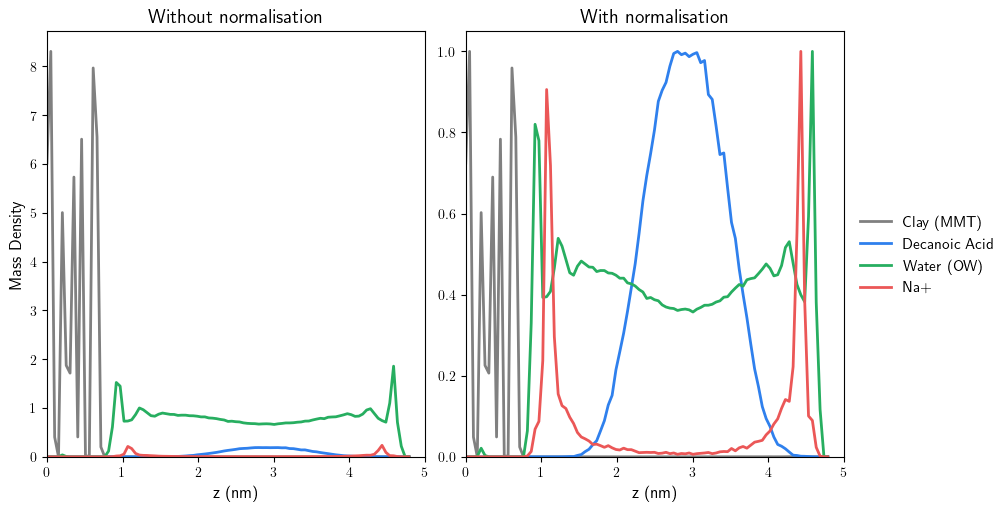

In [2]:
# =============================================================================
# 2. One-Dimensional Mass Density Profiles along z
# =============================================================================
# Calculates mass density perpendicular to the clay surface (z-axis)

import pandas as pd
from MDAnalysis.analysis import lineardensity as lin

atom_groups = [clay_group, deca_group, water_ow, sodium_group]

all_dens = []
z_max = u.dimensions[2]  # z box dimension in Angstroms
for group in atom_groups:
    dens = lin.LinearDensity(group, binsize=0.5).run(start=START_FRAME)

    z_axis = np.linspace(0, z_max, dens.nbins)
    df = pd.DataFrame({
        "z-coordinate": z_axis,
        "mass density": dens.results.z.mass_density,
    })

    # Normalised mass (min-max)
    vals = df["mass density"].values
    df[f"mass density (norm)"] = (vals - vals.min()) / (vals.max() - vals.min())

    all_dens.append(df)

# Plot 1D Linear Density Profiles
fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, layout="constrained", figsize=(10, 5), sharex=True)

# Non-normalised
ax1.plot(all_dens[0]["z-coordinate"] / 10, all_dens[0]["mass density"], label="Clay (MMT)", color="gray", linewidth=2)
ax1.plot(all_dens[1]["z-coordinate"] / 10, all_dens[1]["mass density"], label="Decanoic Acid", color="#2F80ED", linewidth=2)
ax1.plot(all_dens[2]["z-coordinate"] / 10, all_dens[2]["mass density"], label="Water (OW)", color="#27AE60", linewidth=2)
ax1.plot(all_dens[3]["z-coordinate"] / 10, all_dens[3]["mass density"], label="Na+", color="#EB5757", linewidth=2)

# Normalised
ax2.plot(all_dens[0]["z-coordinate"] / 10, all_dens[0]["mass density (norm)"], color="gray", linewidth=2)
ax2.plot(all_dens[1]["z-coordinate"] / 10, all_dens[1]["mass density (norm)"], color="#2F80ED", linewidth=2)
ax2.plot(all_dens[2]["z-coordinate"] / 10, all_dens[2]["mass density (norm)"], color="#27AE60", linewidth=2)
ax2.plot(all_dens[3]["z-coordinate"] / 10, all_dens[3]["mass density (norm)"], color="#EB5757", linewidth=2)

ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax1.set_xlim(0,5)

ax1.set_xlabel("z (nm)", fontsize=12)
ax2.set_xlabel("z (nm)", fontsize=12)
ax1.set_ylabel("Mass Density", fontsize=12)
ax1.set_title("Without normalisation", fontsize=14, fontweight="bold")
ax2.set_title("With normalisation", fontsize=14, fontweight="bold")
fig.legend(fontsize=11, loc="outside center right", frameon=False)


<p style="margin-top:-20px">&nbsp;</p>

#### 7.2.3 Radial Distribution Functions (RDFs) and Coordination Numbers

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;">
<b>🔬 Scientific Meaning:</b><br>
The pair distribution function $g(r)$ measures the probability of finding a particle at distance $r$ from a reference atom relative to an ideal gas of identical bulk density $\rho_\text{bulk}$:
$$g(r) = \frac{1}{4\pi r^2 \rho_\text{bulk}} \frac{dN(r)}{dr}$$
Integrating $g(r)$ up to the first minimum $r_\text{min}$ gives the <b>running coordination number:</b> 
    $N(r) = 4\pi \rho_\text{bulk} \int_0^{r_\text{min}} r^2 g(r) dr$, which represents the average number of coordinating solvent or ligand atoms in the first solvation shell</div>div>

MDAnalysis has a <a href="https://userguide.mdanalysis.org/stable/examples/analysis/structure/average_rdf.html" target="_blank" style="color: #004f71;">tool</a> to compute the radial distribution function between two atoms. It is normalised so that the RDF becomes 1 for large separations in a homogenous system.

In the example system, you should see two hydration shells: 
    
<ul>
  <li><b>$\text{Na}^+-\text{O}_\text{w}$ 1st Hydration Shell:</b> The first peak at $r \approx 2.35\text{ Å}$ corresponds to the inner hydration sphere with a coordination number $N \approx 5$ water molecules.</li>
    <li><b>$\text{Na}^+-\text{O}_\text{w}$ 2nd Hydration Shell:</b> The second peak at $r \approx 4.45\text{ Å}$ corresponds to the outer hydration sphere.</li>
</ul>
</div>


First hydration shell peak position: 2.35 Å
First hydration shell coordination number: 4.62


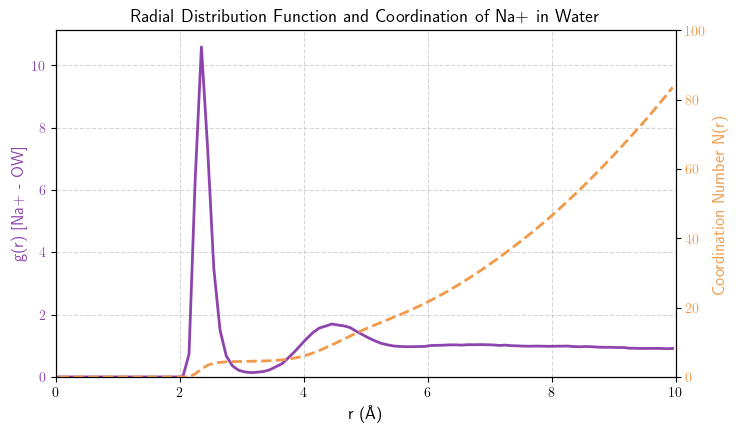

In [3]:
# =============================================================================
# 3. Radial Distribution Functions (RDFs) and Coordination Numbers
# =============================================================================
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.analysis import density

# Na+ to Water Oxygen (OW) RDF: Analyzes cation hydration shell
rdf_na_ow = InterRDF(sodium_group, water_ow, nbins=100, range=(0.0, 10.0))

# Run over equilibrated frames
rdf_na_ow.run(start=START_FRAME)

# Calculate the bulk density of water
D = density.DensityAnalysis(water_ow, delta=1.0)
D.run(start=START_FRAME)
D.results.density.convert_density("A^{-3}")
water_dens = D.results.density.grid

# from the linear density, we know that the bulk density in z is reached around z=28 A, 
# so we find the average density for that "slice" of the box
rho_bulk = water_dens[:, :, 28].mean()

# Calculate running coordination number N(r)
# N(r) = 4 * pi * rho_bulk * integral( r^2 * g(r) dr )
r = rdf_na_ow.results.bins
g_r = rdf_na_ow.results.rdf
dr = r[1] - r[0]
coordination_num = 4.0 * np.pi * rho_bulk * np.cumsum(r**2 * g_r * dr)

fig, ax1 = plt.subplots(figsize=(8, 4.5), sharex=True)

color = "#8E44AD"
ax1.set_xlabel("r (Å)", fontsize=12)
ax1.set_ylabel("g(r) [Na+ - OW]", color=color, fontsize=12)
ax1.plot(r, g_r, color=color, linewidth=2, label="g(r)")
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.set_ylim(bottom=0)
ax1.set_xlim(0, 10)


ax2 = ax1.twinx()
color_coord = "#F2994A"
ax2.set_ylabel("Coordination Number N(r)", color=color_coord, fontsize=12)
ax2.plot(r, coordination_num, color=color_coord, linewidth=2, linestyle="--", label="N(r)")
ax2.tick_params(axis='y', labelcolor=color_coord)
ax2.set_ylim(0, 100)

plt.title("Radial Distribution Function and Coordination of Na+ in Water", fontsize=13, fontweight="bold")

# First hydration shell radius (first minimum after peak)
first_peak_r = r[np.argmax(g_r[:40])]
print(f"First hydration shell peak position: {first_peak_r:.2f} Å")

# Find plateau after first peak
nonzero_indices = np.where(np.abs(coordination_num) > 0.1)[0]
start = nonzero_indices[0]
y2 = coordination_num[start:]
diff = np.diff(y2)
flat = np.abs(diff) <= 0.1
rising = diff > 0.1

for i in range(len(diff) - 1):
        if flat[i] and rising[i + 1]:
            plateau_index = start + i
            plateau_value = coordination_num[plateau_index]

print(f"First hydration shell coordination number: {plateau_value:.2f}")

<p style="margin-top:-20px">&nbsp;</p>

#### 7.2.4 Organic Molecule Clustering & Micelle Formation

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;">
<b>🔬 Scientific Meaning:</b><br>
Surfactants and organic fatty acids like decanoic acid ($\text{CH}_3(\text{CH}_2)_8\text{COOH}$) are amphiphilic, possessing a polar hydrophilic headgroup and a non-polar hydrophobic hydrocarbon tail:
<ul>
  <li><b>Hydrophobic Effect & Self-Assembly:</b> In aqueous environments or near mineral surfaces, water molecules form structured hydrogen-bonded cages around hydrophobic tails. To minimize this entropic penalty, hydrophobic tails associate with one another, forming pre-micellar aggregates.</li>
  <li><b>Intermolecular Contact Criterion:</b> Two surfactant molecules are considered in contact (part of the same cluster) if <b>any carbon atom</b> of molecule $i$ is within the van der Waals contact distance ($d \le 5.0\text{ Å}$) of <b>any carbon atom</b> of molecule $j$.</li>
  <li><b>Cluster Size & Aggregation Number ($N_\text{agg}$):</b> Tracking the number of distinct clusters and the size of the largest cluster over time allows us to monitor micelle nucleation, growth, and thermodynamic stability.</li>
</ul>
</div>

**Building Custom Analyses in MDAnalysis:**<br>
MDAnalysis provides low-level mathematical and geometric primitives that make it straightforward to implement custom algorithms without specialized plugins. In the code below, we combine:
1. **Per-residue carbon selection:** Selecting all aliphatic and backbone carbon atoms (`name C*`) for each individual decanoic acid molecule.
2. **PBC-aware inter-residue distance calculations:** Using `MDAnalysis.lib.distances.distance_array` between the carbon sets of pairs of molecules $(i, j)$ to find the minimum carbon–carbon distance ($\min d_\text{PBC}(\text{C}_i, \text{C}_j)$) across periodic boundary conditions.
3. **Graph-based cluster detection:** Marking an adjacency edge when $\min d_{\text{C}-\text{C}} \le 5.0\text{ Å}$ and using `scipy.sparse.csgraph.connected_components` to identify clusters of mutually contacting molecules.

In the example system, you should see that the cluster grows in size until the system is fully equilibrated.


Total decanoic acid molecules in system: 10
Average largest cluster size during analysis: 9.60 molecules
Average number of distinct clusters: 1.21


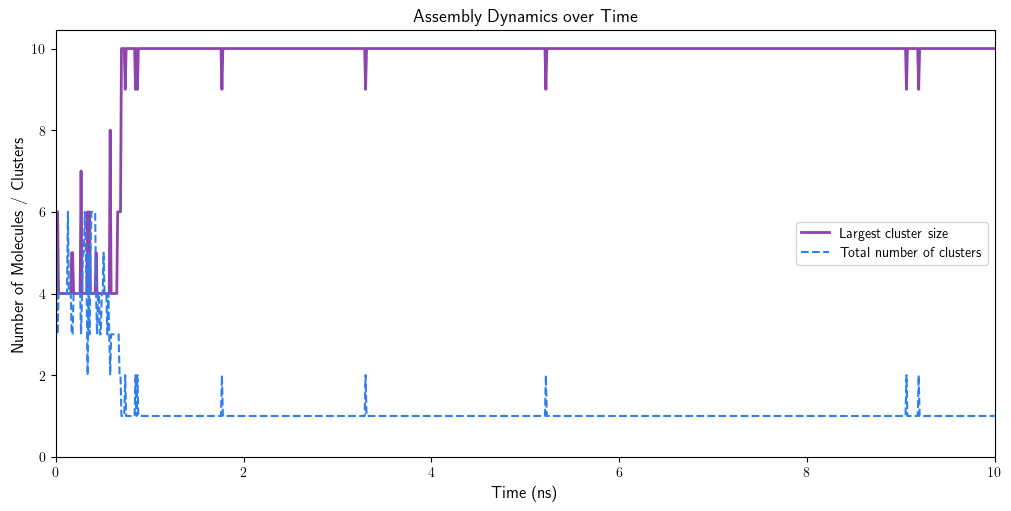

In [4]:
# =============================================================================
# 5. Organic Molecule Clustering and Micelle Formation (Custom Analysis)
# =============================================================================
# Demonstrates using MDAnalysis building blocks (distance_array + PBC) to identify
# surfactant clusters and track micelle assembly over time.

import MDAnalysis.lib.distances as mda_dist
from scipy.sparse import csgraph
from scipy.sparse import csr_matrix

# Cutoff distance between carbon atoms to define a contact (in Angstroms)
# 5.0 A corresponds to the carbon-carbon van der Waals first coordination distance
CONTACT_CUTOFF_A = 4.5

# Pre-select all carbon atoms for each decanoic acid molecule
deca_residues = deca_group.residues
n_deca_mols = len(deca_residues)
res_carbons = [res.atoms.select_atoms("name C*") for res in deca_residues]

times_ns = []
n_clusters_list = []
largest_cluster_size = []
all_cluster_sizes_eq = []

# iterate over every frame
for ts in u.trajectory:
    
    
    # 1. Extract carbon coordinates for each molecule in the current frame
    coords_by_res = [carbons.positions for carbons in res_carbons]
    
    # 2. Build the adjacency matrix across all pairs of molecules (i, j)
    adj_matrix = np.zeros((n_deca_mols, n_deca_mols), dtype=int)
    
    for i in range(n_deca_mols):
        for j in range(i + 1, n_deca_mols):
            # Compute PBC-corrected pairwise distances between all carbon atoms in molecule i and molecule j
            # Two molecules are in contact if the minimum C-C distance is within the cutoff
            dist_c_c = mda_dist.distance_array(coords_by_res[i], coords_by_res[j], box=ts.dimensions)
            if dist_c_c.min() <= CONTACT_CUTOFF_A:
                adj_matrix[i, j] = 1
                adj_matrix[j, i] = 1
    
    # 3. Find connected components (clusters) using graph theory
    graph = csr_matrix(adj_matrix)
    n_components, labels = csgraph.connected_components(graph, directed=False)
    
    # 4. Calculate sizes of each cluster in this frame
    _, cluster_sizes = np.unique(labels, return_counts=True)
    
    times_ns.append(ts.time / 1000.0)
    n_clusters_list.append(n_components)
    largest_cluster_size.append(np.max(cluster_sizes))

# Plotting the clustering and micelle analysis results
fig, ax1 = plt.subplots(figsize=(10, 5), layout="constrained")

# Left: Time series of largest cluster size
ax1.plot(times_ns, largest_cluster_size, color="#8E44AD", linewidth=2, label="Largest cluster size")
ax1.plot(times_ns, n_clusters_list, color="#2F80ED", linewidth=1.5, linestyle="--", label="Total number of clusters")
ax1.set_xlabel("Time (ns)", fontsize=12)
ax1.set_xlim(0, 10)
ax1.set_ylim(bottom=0)
ax1.set_ylabel("Number of Molecules / Clusters", fontsize=12)
ax1.set_title("Assembly Dynamics over Time", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)

# Print summary metrics
print(f"Total decanoic acid molecules in system: {n_deca_mols}")
print(f"Average largest cluster size during analysis: {np.mean(largest_cluster_size):.2f} molecules")
print(f"Average number of distinct clusters: {np.mean(n_clusters_list):.2f}")


<br>

---

## 🖼️ 8. Trajectory & Structure Visualization in VMD

<div style="background-color:rgba(142,68,173,0.08);padding: 10px 14px;border-left: 4px solid #8E44AD;margin: 10px 0 16px 0;border-radius: 4px;"><b>💡 Why this section matters</b><br>Visual inspection confirms structural integrity, adsorption geometry, and dynamic behavior of organics and ions at the mineral interface.</div>

### 🎨 Recommended VMD Representation Settings

1. Load `prod.gro` into VMD, then load `prod.xtc` into the same molecule.
2. **Clay Framework (MMT)**:
   - Selection: `resname MMT`
   - Drawing Method: `Licorice`
3. **Decanoic Acid (DECA)**:
   - Selection: `resname DECA`
   - Drawing Method: `CPK`
4. **Sodium Ions (Na⁺)**:
   - Selection: `resname Na`
   - Drawing Method: `VDW` and change the sphere scale to 0.2 or 0.3 
5. **Water Solvent (SOL)**:
   - Selection: `resname SOL`
   - Drawing Method: `QuickSurf`
   - Material: `Ghost`
   - Coloring Method: `ColorID 8`